In [1]:
import numpy as np
import cvxpy as cp
from scipy.stats import norm
import scipy

   

K = 1000
t0 = cp.Parameter(K, nonneg=True)
delta = cp.Variable(K)
x = np.linspace(0, 1, K)
eps = 0.2
c_bar = 0.3

def error_prob(c_bar, t):
   res = scipy.integrate.simps(norm.cdf(c_bar - t - np.linspace(0, 1, K)), np.linspace(0, 1, K))
   print(res)
   return res

eps_prime = cp.Parameter(1, nonneg=True)

f = cp.Parameter(K, nonneg=True)


eta = 0.05
obj = cp.Minimize(cp.sum(t0 + delta) * (1/K))
constraints = [ t0 + delta >= 0, delta >= -eta, delta <= eta, (-f @ delta) * (1/K) <= eps_prime]
prob = cp.Problem(obj, constraints)

M = 100
t0.value = np.ones(K) * 1.5
eps_prime.value = np.array([eps - error_prob(c_bar, t0.value)])
f.value = norm.pdf(-x)

costs = []
error_ps = []
for i in range(M):
    prob.solve()
    cost = prob.value
    
    t = t0.value + delta.value
    error_p = error_prob(c_bar, t)
    costs.append(cost)
    error_ps.append(error_p)

    print(delta.value)
    #update parameters
    t0.value = t
    f.value = norm.pdf(c_bar - t - x)
    eps_prime.value = np.array([np.maximum(eps - error_p, 0)])


print(costs)
print(error_ps)
print(t)

0.051215442413629415
0.056475357051719605
[-0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0

[-0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0

0.20172864003420607
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05

0.2043568300816477
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.04999999  0.04999999 -0.04999997 -0.04999999 -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05 

0.20844546649962736
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.04999999  0.04999999
 -0.04999994 -0.04999998  0.05       -0.05        0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05        0.05        0.05        0.05
  0.05       -0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05      

0.212207736972207
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05       -0.05        0.05       -0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05       -0.04378155 -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05        0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05  

0.21624966284339447
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05        0.05

0.2202629340918417
[ 0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05       -0.05       -0.05       -0.05       -0.05       -0.05
 -0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05        0.05        0.05
  0.05        0.05        0.05        0.05 

[1.450000000004064, 1.4000000000177826, 1.3500000000269292, 1.3000000000293768, 1.2500000000331926, 1.2000000000453757, 1.1500000000801052, 1.1000000001824042, 1.050000000247249, 1.0000000002678295, 0.9500000002983996, 0.9000000003012114, 0.8500000003061022, 0.8000000003079667, 0.7500000003660942, 0.7000000003686087, 0.6697830137863159, 0.6606130017318389, 0.6531165246016897, 0.6471465827779044, 0.6425405055787818, 0.6390352676359992, 0.6364035291823829, 0.6344505165431008, 0.6329528800666774, 0.631719407417047, 0.6306646843316421, 0.6296290010444622, 0.6285924759151824, 0.6275600060965002, 0.6265252413176168, 0.6254958484525349, 0.6244631171053079, 0.6234367091844228, 0.6224063262012296, 0.6213826794103485, 0.6203546264940728, 0.619333695048584, 0.618308013918826, 0.6172897897412755, 0.6162664880594545, 0.6152511856467648, 0.6142299416142051, 0.6132177246781862, 0.6121983875351246, 0.6111893696461326, 0.6101718871443509, 0.6091661183733195, 0.6081506228728273, 0.6071479642381254, 0.60

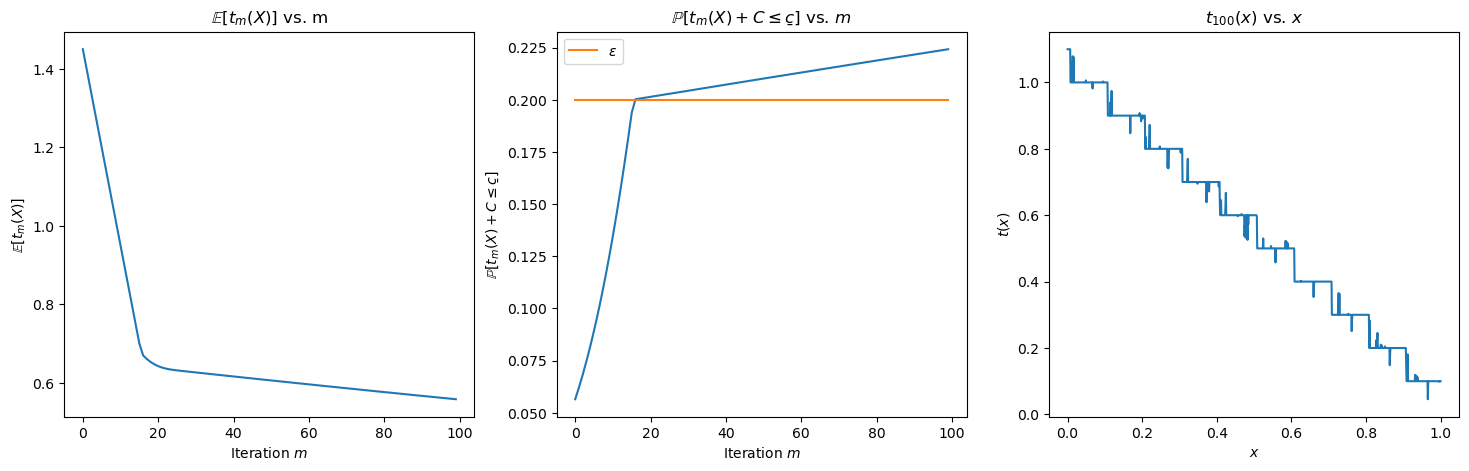

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[2].plot(x, t)
ax[2].set_xlabel(r"$x$")
ax[2].set_ylabel(r"$t(x)$")
ax[2].set_title(r"$t_{100}(x)$" + " vs. " + r"$x$")
ax[0].plot(list(range(M)), costs)
ax[0].set_ylabel(r"$\mathbb{E}[t_{m}(X)]$")
ax[0].set_title(r"$\mathbb{E}[t_{m}(X)]$" + " vs. m")
ax[0].set_xlabel("Iteration " + r"$m$")
ax[1].set_xlabel("Iteration " + r"$m$")
ax[1].plot(list(range(M)), error_ps)
ax[1].plot(list(range(M)), eps * np.ones(len(error_ps)), label=r"$\epsilon$")
ax[1].legend()
ax[1].set_ylabel(r"$\mathbb{P}[t_{m}(X) + C \leq c\underbar]$")
ax[1].set_title(r"$\mathbb{P}[t_{m}(X) + C \leq c\underbar]$" + " vs. " + r"$m$")
plt.savefig("linearized_optimization.pdf", bbox_inches="tight")